In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.25
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [3]:
PREFIX_PATH = "../../.."
mcscan_df = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_128_fp16.csv")
mcscan_up_sweep_df = pd.read_csv(f"{PREFIX_PATH}/bench_results_row_scan_128_fp16.csv")

mcscanul1_df = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_multi_cube_128_fp16.csv")
mcscanul1_up_sweep_df = pd.read_csv(f"{PREFIX_PATH}/bench_results_block_scan_128_fp16.csv")

In [4]:
mcscan_df.head()

,operator,dtype,size,density,outputsize,time_us
0,mcscan_128,fp16,327680,None,327680,135.46
1,mcscan_128,fp16,5570560,None,5570560,226.74
2,mcscan_128,fp16,10813440,None,10813440,332.53
3,mcscan_128,fp16,16056320,None,16056320,440.48
4,mcscan_128,fp16,21299200,None,21299200,533.56


In [5]:
mcscan_up_sweep_df.head()

,operator,dtype,size,density,outputsize,time_us
0,row_scan_128,fp16,327680,None,327680,108.62
1,row_scan_128,fp16,5570560,None,5570560,170.75
2,row_scan_128,fp16,10813440,None,10813440,228.73
3,row_scan_128,fp16,16056320,None,16056320,296.52
4,row_scan_128,fp16,21299200,None,21299200,348.41


In [18]:


breakdown_mcscan = pd.merge(mcscan_up_sweep_df[['size', 'time_us']], mcscan_df[['size', 'time_us']], on='size', suffixes=('_up_sweep', '_mcscan'))
breakdown_mcscan = breakdown_mcscan.sort_values(by='size')
breakdown_mcscan["time_us_down_sweep"] = breakdown_mcscan["time_us_mcscan"]- breakdown_mcscan["time_us_up_sweep"]
breakdown_mcscan = breakdown_mcscan[['size', 'time_us_up_sweep', 'time_us_down_sweep']]
breakdown_mcscan.rename(columns={ "time_us_up_sweep": "MCScan (Up)", "time_us_down_sweep": "MCScan (Down)"}, inplace=True)
breakdown_mcscan = breakdown_mcscan.sort_values(by='size')
breakdown_mcscan["size"] = (breakdown_mcscan["size"] * 1e-6).map(lambda x: f"{x:.1f}M")
breakdown_mcscan.set_index('size', inplace=True)

breakdown_mcscanul1 = pd.merge(mcscanul1_up_sweep_df[['size', 'time_us']], mcscanul1_df[['size', 'time_us']], on='size', suffixes=('_up_sweep', '_mcscanul1'))
breakdown_mcscanul1["time_us_down_sweep"] = breakdown_mcscanul1["time_us_mcscanul1"]- breakdown_mcscanul1["time_us_up_sweep"]
breakdown_mcscanul1 = breakdown_mcscanul1[['size', 'time_us_up_sweep', 'time_us_down_sweep']]
breakdown_mcscanul1.rename(columns={ "time_us_up_sweep": "MCSCANUL1 (Up)", "time_us_down_sweep": "MCSCANUL1 (Down)"}, inplace=True)
breakdown_mcscanul1 = breakdown_mcscanul1.sort_values(by='size')

breakdown_mcscanul1["size"] = (breakdown_mcscanul1["size"] * 1e-6).map(lambda x: f"{x:.1f}M")

breakdown_mcscanul1.set_index('size', inplace=True)


In [19]:
breakdown_mcscanul1.head()

,MCSCANUL1 (Up),MCSCANUL1 (Down)
size,,
0.3M,123.61,-1.84
5.6M,171.02,24.37
10.8M,244.62,27.94
16.1M,314.55,34.87
21.3M,374.35,55.90


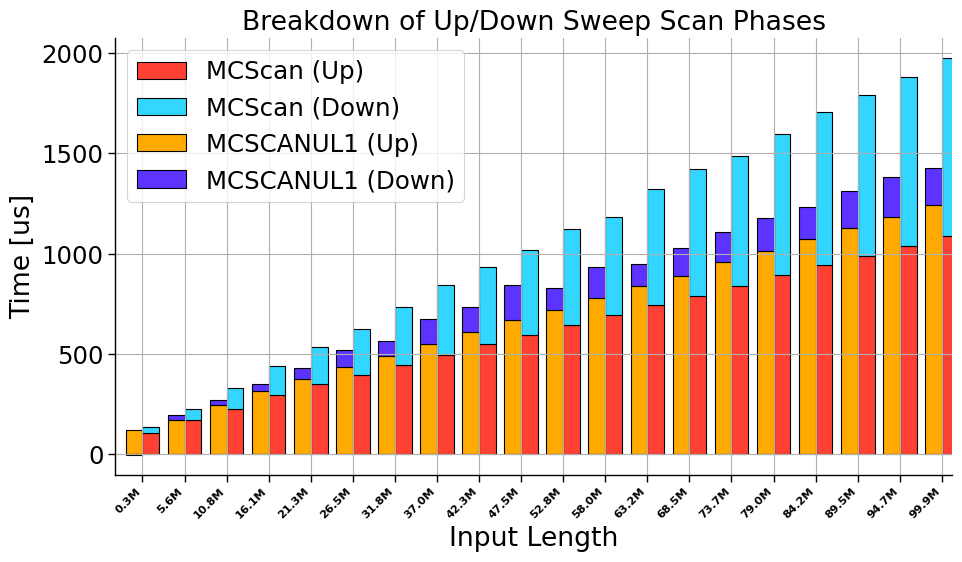

<Figure size 870x627 with 0 Axes>

In [21]:

fig, ax = plt.subplots(figsize=(10, 6))


mcscan_colors = ["#FF4133", "#33D6FF"]
mcscanul1_colors = ["#FFAA00", "#5C33FF"]

breakdown_mcscan.plot(kind='bar', ax=ax, position=0, width=0.4, color=mcscan_colors, stacked=True, edgecolor='black')
breakdown_mcscanul1.plot(kind='bar', ax=ax, position=1, width=0.4, color=mcscanul1_colors, stacked=True, edgecolor='black')


plt.title('Breakdown of Up/Down Sweep Scan Phases')
plt.xlabel('Input Length')
plt.xticks(rotation=45, ha='right', fontsize=8, fontweight='bold', fontname='DejaVu Sans')
plt.ylabel('Time [us]')
plt.legend(markerscale=1.2)
sns.despine(right = True)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/breakdown_scan_up_down_sweeps.png")
plt.show()
plt.clf()